In [1]:
from typing import TypedDict, Annotated
from langchain_core.messages import AnyMessage
import operator

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [2]:
from langgraph.types import interrupt

def process_task(state: MessagesState):
    print(f"현재 messages: {state['messages']}")

    approval = interrupt("계속 진행할까요? (True/False)")

    if approval:
        print("승인되었습니다!")
        return {"messages": ["작업이 성공적으로 완료됨"]}
    else:
        print("거부되었습니다.")
        return {"messages": ["작업이 취소됨"]}

In [14]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

graph_builder = StateGraph(MessagesState)

graph_builder.add_node("process_task", process_task)

graph_builder.add_edge(START, "process_task")
graph_builder.add_edge("process_task", END)

checkpointer = InMemorySaver()
graph = graph_builder.compile(checkpointer=checkpointer)

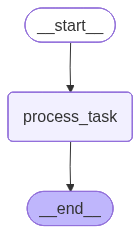

In [15]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
config = {"configurable": {"thread_id": "1"}}

In [22]:
result = graph.invoke({"messages": ["시작"]}, config=config)

현재 messages: ['시작', '작업이 성공적으로 완료됨', '시작']


In [19]:
result

{'messages': ['시작'],
 '__interrupt__': [Interrupt(value='계속 진행할까요? (True/False)', id='c93df12dcb73bf6d6f05ef551b8595b2')]}

In [20]:
result.get("__interrupt__")

[Interrupt(value='계속 진행할까요? (True/False)', id='c93df12dcb73bf6d6f05ef551b8595b2')]

In [21]:
from langgraph.types import Command

graph.invoke(Command(resume=True), config=config)

현재 messages: ['시작']
승인되었습니다!


{'messages': ['시작', '작업이 성공적으로 완료됨']}

In [23]:
result = graph.invoke({"messages": ["시작"]}, config=config)

현재 messages: ['시작', '작업이 성공적으로 완료됨', '시작', '시작']


In [24]:
result

{'messages': ['시작', '작업이 성공적으로 완료됨', '시작', '시작'],
 '__interrupt__': [Interrupt(value='계속 진행할까요? (True/False)', id='2ecb48b46d1169235cc33c570438c615')]}

In [25]:
graph.invoke(Command(resume=False), config=config)

현재 messages: ['시작', '작업이 성공적으로 완료됨', '시작', '시작']
거부되었습니다.


{'messages': ['시작', '작업이 성공적으로 완료됨', '시작', '시작', '작업이 취소됨']}